In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [4]:
# ===============================
# Task 1 : Dataset Exploration
# ===============================

import pandas as pd

# Column names (Banknote Authentication Dataset)
columns = [
    'Variance',
    'Skewness',
    'Curtosis',
    'Entropy',
    'Class'
]

# Load dataset
df = pd.read_csv(
    "/data_banknote_authentication.txt",
    header=None,
    names=columns
)

print("="*50)
print("First Five Samples")
print("="*50)

print(df.head())

print("\n")

print("="*50)
print("Dataset Dimensions")
print("="*50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n")

print("="*50)
print("Missing Values")
print("="*50)

print(df.isnull().sum())

print("\n")

print("="*50)
print("Descriptive Statistics")
print("="*50)

print(df.describe())

print("\n")

print("="*50)
print("Dataset Information")
print("="*50)

print(df.info())

First Five Samples
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


Dataset Dimensions
Rows    : 1372
Columns : 5


Missing Values
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


Descriptive Statistics
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     

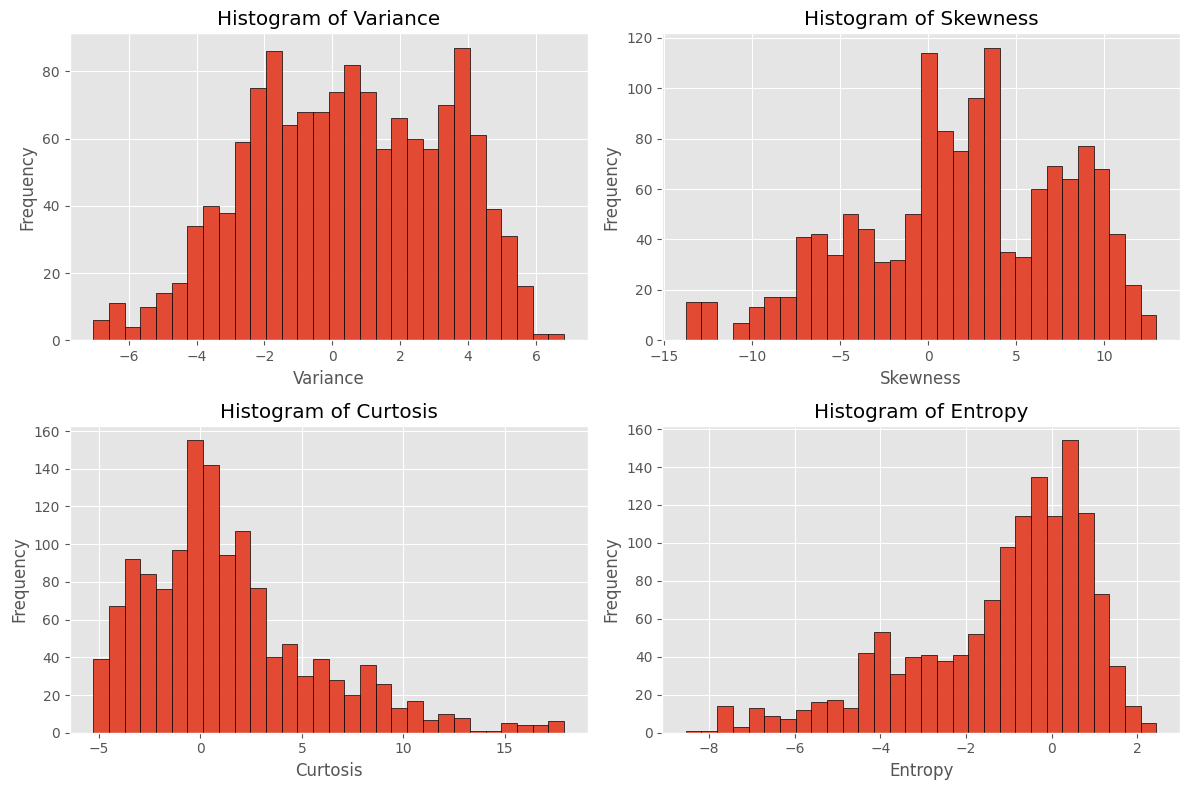

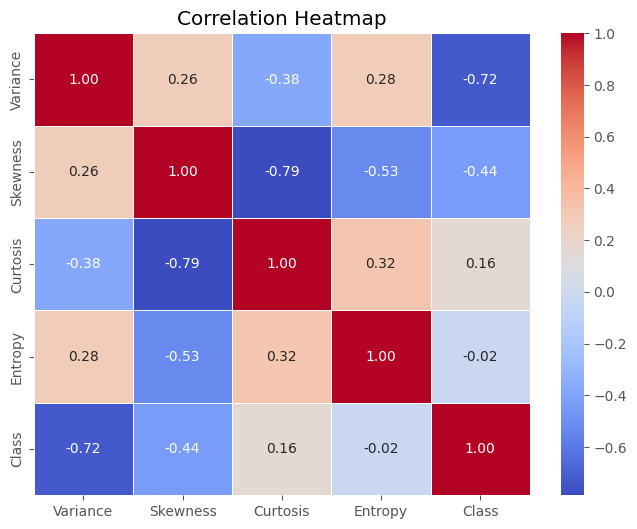

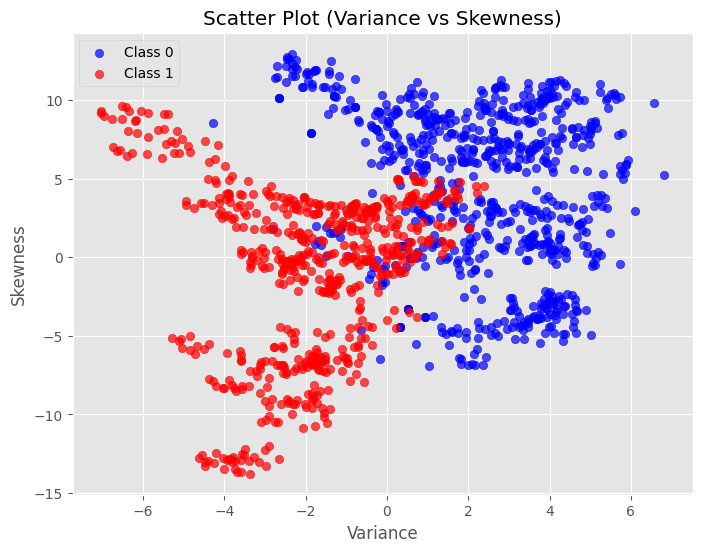

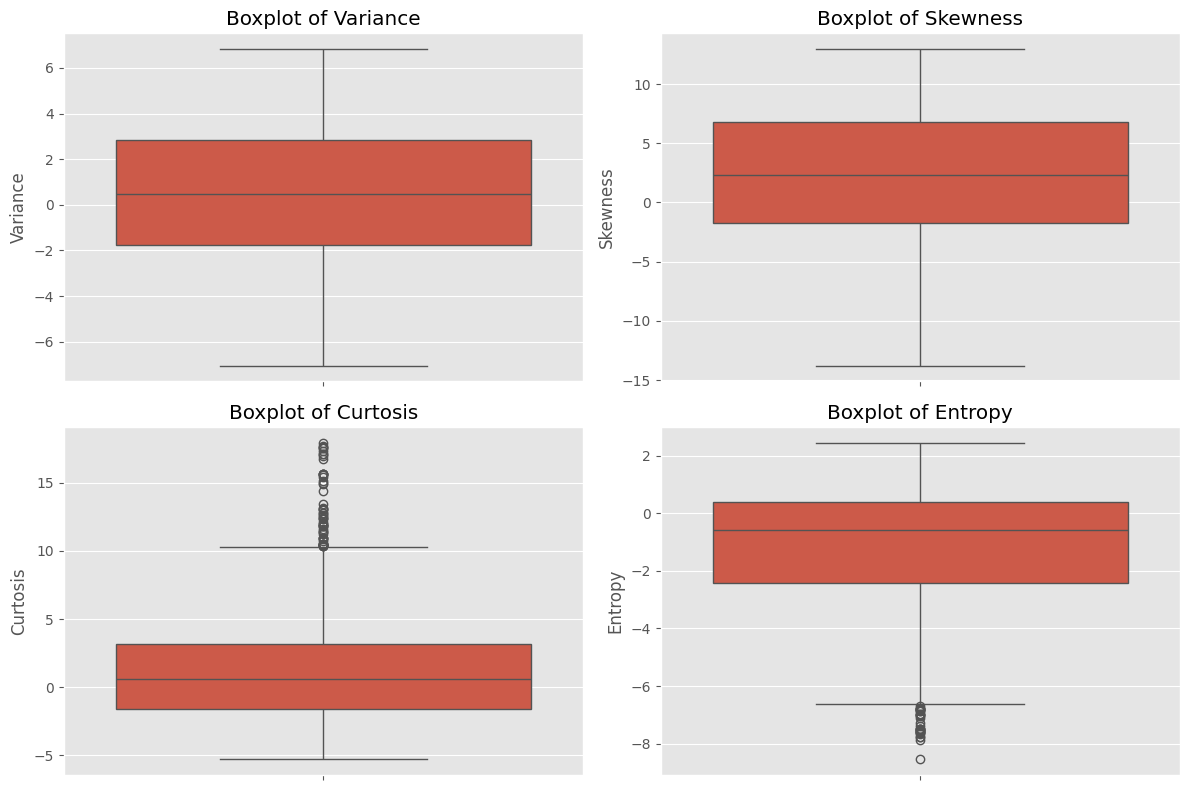

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']

df = pd.read_csv(
    "/data_banknote_authentication.txt",
    header=None,
    names=columns
)

# Better-looking plots
plt.style.use('ggplot')


# ============================================
# Histograms
# ============================================

features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

plt.figure(figsize=(12,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)
    plt.hist(df[feature], bins=30, edgecolor='black')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# ============================================
# Correlation Heatmap
# ============================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# ============================================
# Scatter Plot
# ============================================

plt.figure(figsize=(8,6))

colors = {0:'blue',1:'red'}

for cls in df['Class'].unique():
    subset = df[df['Class']==cls]

    plt.scatter(
        subset['Variance'],
        subset['Skewness'],
        color=colors[cls],
        label=f'Class {cls}',
        alpha=0.7
    )

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Scatter Plot (Variance vs Skewness)")
plt.legend()
plt.show()

# ============================================
# Boxplots
# ============================================

plt.figure(figsize=(12,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)

    sns.boxplot(y=df[feature])

    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Features
X = df.iloc[:, :-1].values

# Target
y = df.iloc[:, -1].values

# Normalize features
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

print("First 5 Normalized Samples:")
print(X[:5])

# 80% Training
# 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

First 5 Normalized Samples:
[[0.76900389 0.83964273 0.10678269 0.73662766]
 [0.83565902 0.82098209 0.12180412 0.64432563]
 [0.78662859 0.41664827 0.31060805 0.78695091]
 [0.75710505 0.87169921 0.05492063 0.45043964]
 [0.53157807 0.34866247 0.42466237 0.6873619 ]]
Training Samples : 1097
Testing Samples  : 275


In [27]:
class MyPerceptron:

    def __init__(self, learning_rate=0.01, epochs=50):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        # Store values for plotting later
        self.errors = []
        self.weight_history = []
        self.bias_history = []


    def initialize_parameters(self, n_features):

        self.weights = np.zeros(n_features)

        self.bias = 0

    def activation(self, x):

        if x >= 0:
            return 1

        return 0

    def predict_single(self, x):

      linear_output = np.dot(x, self.weights) + self.bias
      return self.activation(linear_output)


    def predict(self, X):

        predictions = []

        for x in X:
            predictions.append(self.predict_single(x))

        return np.array(predictions)

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.initialize_parameters(n_features)

        for epoch in range(self.epochs):

            errors = 0

            for i in range(n_samples):

                prediction = self.predict_single(X[i])

                update = self.learning_rate * (y[i] - prediction)

                self.weights += update * X[i]

                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

            self.weight_history.append(self.weights.copy())

            self.bias_history.append(self.bias)

            print(f"Epoch {epoch+1}")

            print(f"Misclassified Samples : {errors}")

            print(f"Weights : {self.weights}")

            print(f"Bias : {self.bias}")

            print("-"*60)


myperceptron = MyPerceptron(
    learning_rate=0.01,
    epochs=50
)
myperceptron.fit(X_train, y_train)

Epoch 1
Misclassified Samples : 171
Weights : [-0.06792364 -0.04617278 -0.05904233  0.02213631]
Bias : 0.07
------------------------------------------------------------
Epoch 2
Misclassified Samples : 101
Weights : [-0.08380509 -0.06774466 -0.08105979  0.00775587]
Bias : 0.09999999999999999
------------------------------------------------------------
Epoch 3
Misclassified Samples : 43
Weights : [-0.08780541 -0.07827122 -0.08945257  0.00240271]
Bias : 0.10999999999999999
------------------------------------------------------------
Epoch 4
Misclassified Samples : 43
Weights : [-0.09081985 -0.08978894 -0.09123274  0.00439111]
Bias : 0.11999999999999998
------------------------------------------------------------
Epoch 5
Misclassified Samples : 57
Weights : [-0.09878964 -0.09827279 -0.09836367  0.0110804 ]
Bias : 0.12999999999999998
------------------------------------------------------------
Epoch 6
Misclassified Samples : 43
Weights : [-0.0971687  -0.10179894 -0.10908865  0.0144443 ]
Bia

In [29]:
# ============================================
# Task 5 : Model Training
# ============================================

# Create the Perceptron model
myperceptron = MyPerceptron(
    learning_rate=0.01,
    epochs=50
)

# Train the model
myperceptron.fit(X_train, y_train)

print("\nTraining Completed Successfully!")

Epoch 1
Misclassified Samples : 171
Weights : [-0.06792364 -0.04617278 -0.05904233  0.02213631]
Bias : 0.07
------------------------------------------------------------
Epoch 2
Misclassified Samples : 101
Weights : [-0.08380509 -0.06774466 -0.08105979  0.00775587]
Bias : 0.09999999999999999
------------------------------------------------------------
Epoch 3
Misclassified Samples : 43
Weights : [-0.08780541 -0.07827122 -0.08945257  0.00240271]
Bias : 0.10999999999999999
------------------------------------------------------------
Epoch 4
Misclassified Samples : 43
Weights : [-0.09081985 -0.08978894 -0.09123274  0.00439111]
Bias : 0.11999999999999998
------------------------------------------------------------
Epoch 5
Misclassified Samples : 57
Weights : [-0.09878964 -0.09827279 -0.09836367  0.0110804 ]
Bias : 0.12999999999999998
------------------------------------------------------------
Epoch 6
Misclassified Samples : 43
Weights : [-0.0971687  -0.10179894 -0.10908865  0.0144443 ]
Bia

MODEL EVALUATION
Accuracy  : 0.9891
Precision : 0.9917
Recall    : 0.9836
F1-score  : 0.9877

Confusion Matrix
[[152   1]
 [  2 120]]


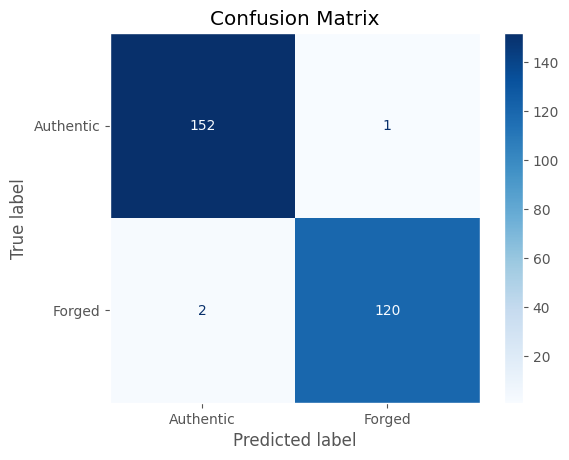

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# ============================================
# Task 6 : Model Evaluation
# ============================================

# Predictions on test set
y_pred = myperceptron.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print("="*45)
print("MODEL EVALUATION")
print("="*45)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Authentic", "Forged"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

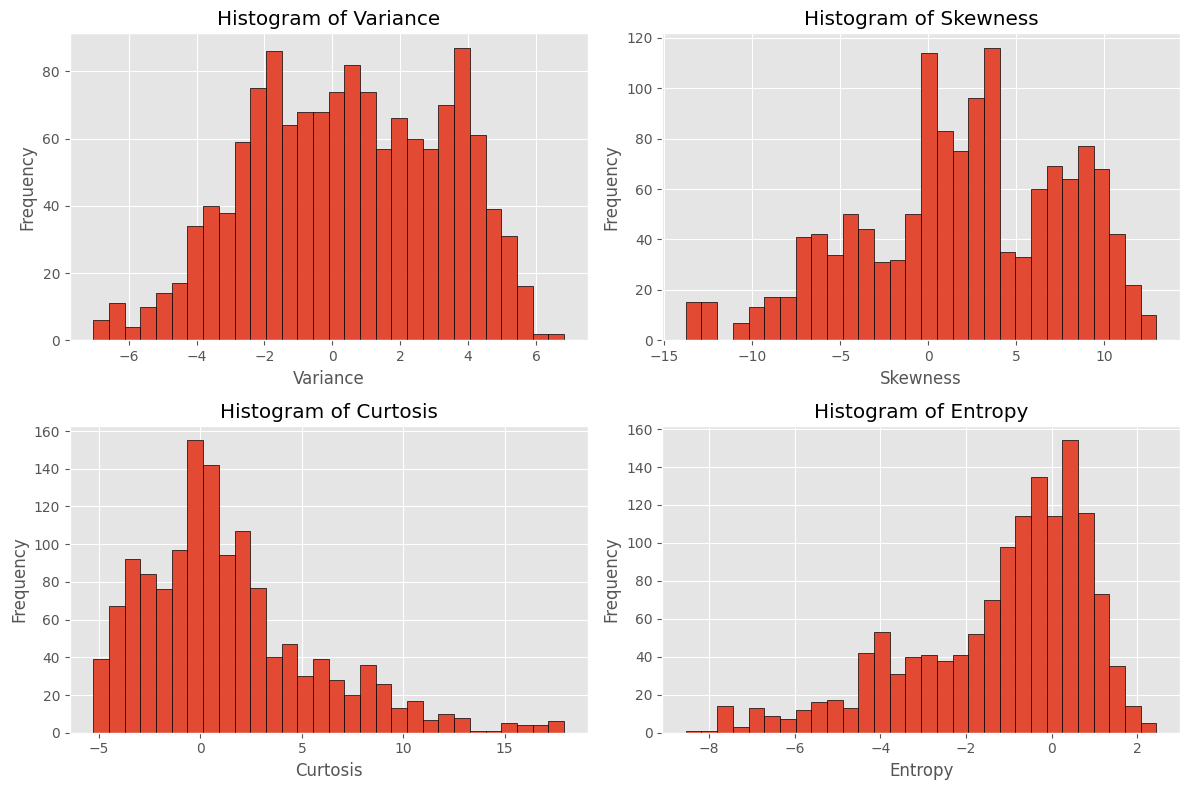

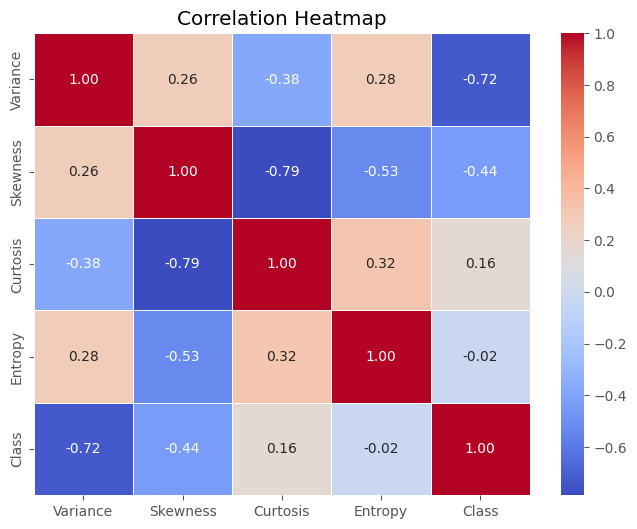

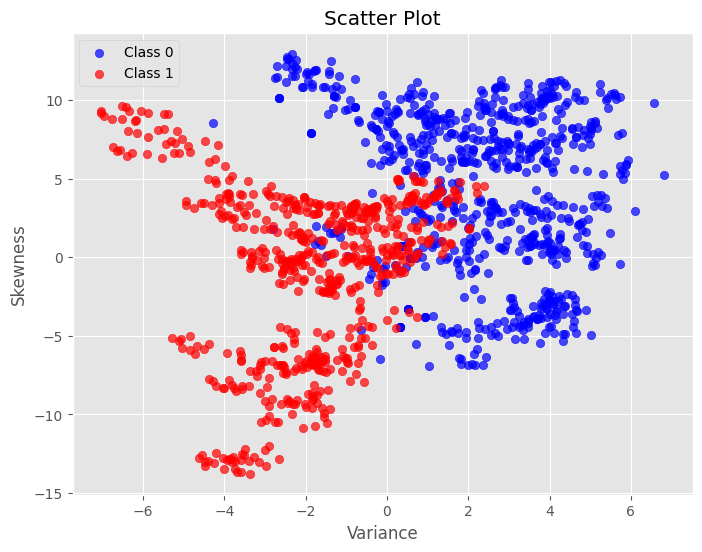

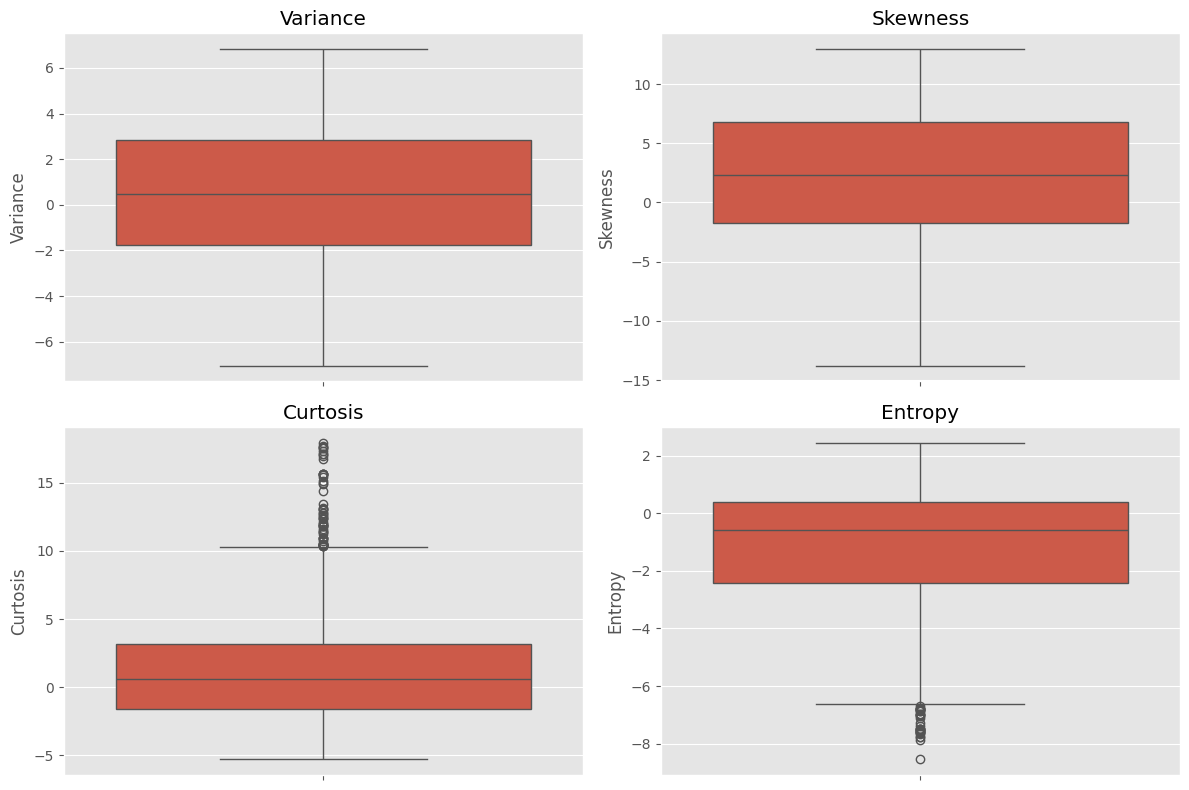

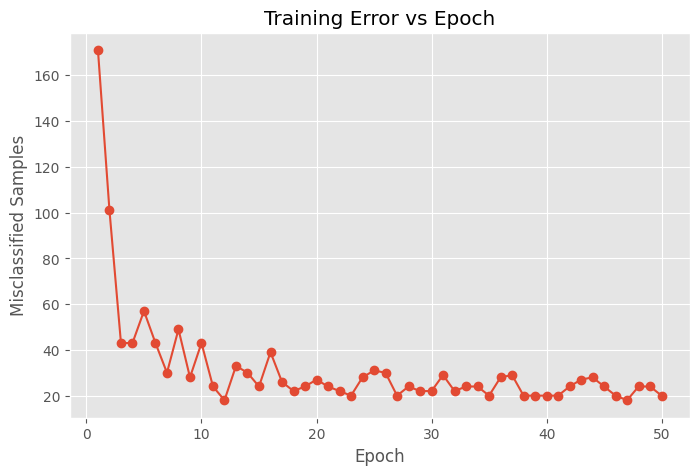

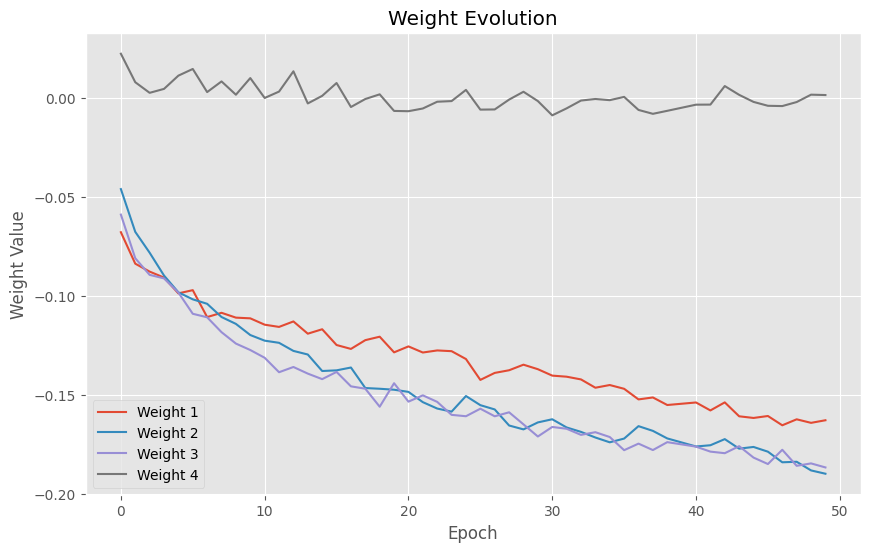

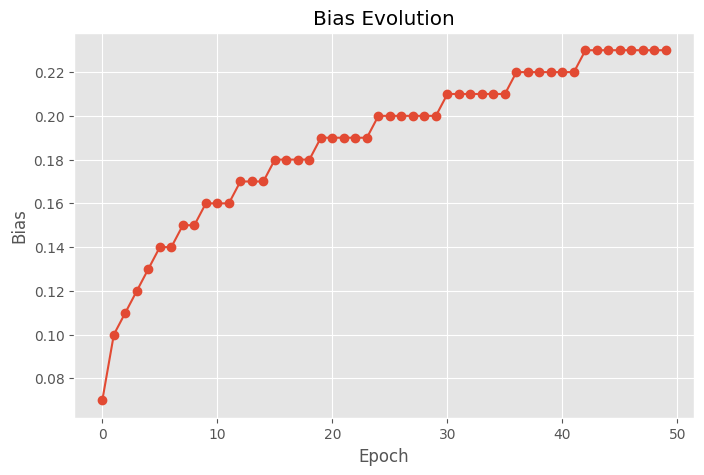

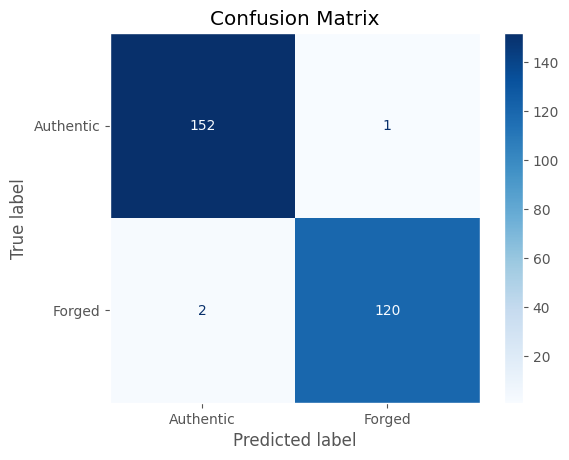

Epoch 1
Misclassified Samples : 171
Weights : [-0.00679236 -0.00461728 -0.00590423  0.00221363]
Bias : 0.007
------------------------------------------------------------
Epoch 2
Misclassified Samples : 101
Weights : [-0.00838051 -0.00677447 -0.00810598  0.00077559]
Bias : 0.010000000000000002
------------------------------------------------------------
Epoch 3
Misclassified Samples : 43
Weights : [-0.00878054 -0.00782712 -0.00894526  0.00024027]
Bias : 0.011000000000000003
------------------------------------------------------------
Epoch 4
Misclassified Samples : 43
Weights : [-0.00908198 -0.00897889 -0.00912327  0.00043911]
Bias : 0.012000000000000004
------------------------------------------------------------
Epoch 5
Misclassified Samples : 57
Weights : [-0.00987896 -0.00982728 -0.00983637  0.00110804]
Bias : 0.013000000000000005
------------------------------------------------------------
Epoch 6
Misclassified Samples : 43
Weights : [-0.00971687 -0.01017989 -0.01090887  0.00144443

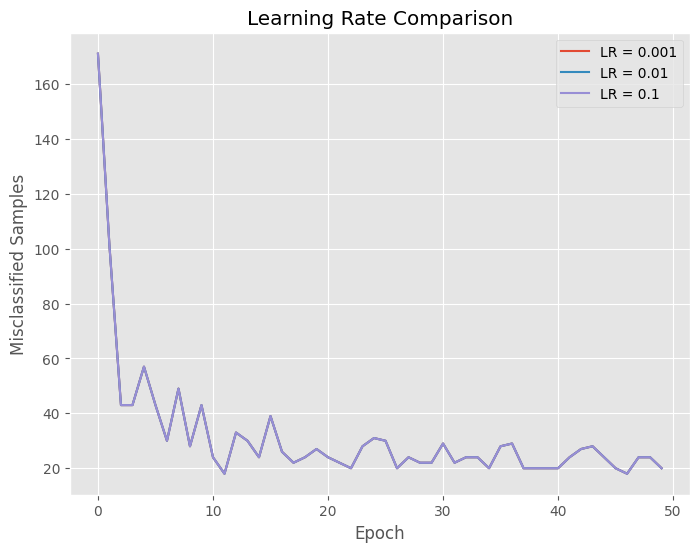

Epoch 1
Misclassified Samples : 247
Weights : [-0.06425077 -0.04360273]
Bias : 0.05
------------------------------------------------------------
Epoch 2
Misclassified Samples : 187
Weights : [-0.07514512 -0.0426944 ]
Bias : 0.060000000000000005
------------------------------------------------------------
Epoch 3
Misclassified Samples : 200
Weights : [-0.07861356 -0.044754  ]
Bias : 0.060000000000000005
------------------------------------------------------------
Epoch 4
Misclassified Samples : 183
Weights : [-0.08194881 -0.04566531]
Bias : 0.07
------------------------------------------------------------
Epoch 5
Misclassified Samples : 180
Weights : [-0.07722296 -0.04665331]
Bias : 0.07
------------------------------------------------------------
Epoch 6
Misclassified Samples : 189
Weights : [-0.07843293 -0.04493673]
Bias : 0.060000000000000005
------------------------------------------------------------
Epoch 7
Misclassified Samples : 185
Weights : [-0.0848141  -0.04344929]
Bias : 0.0

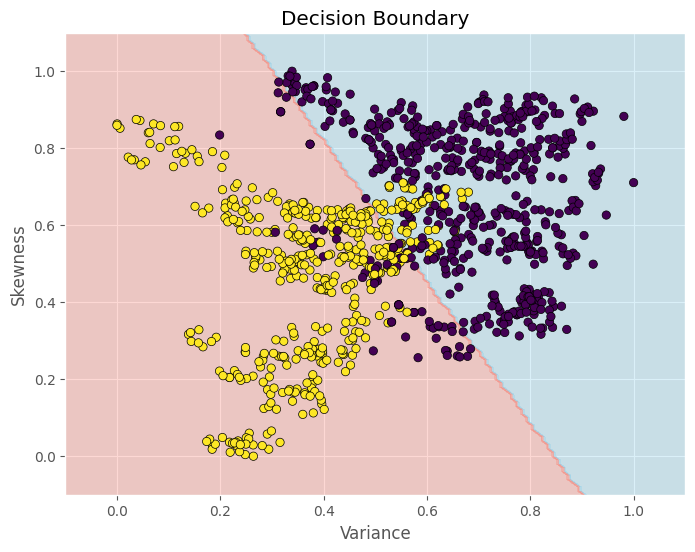

In [35]:
# Task 7

# ============================================
# Histogram of Features
# ============================================

import matplotlib.pyplot as plt

features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

plt.figure(figsize=(12,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)

    plt.hist(df[feature], bins=30, edgecolor='black')

    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# ============================================
# Correlation Heatmap
# ============================================

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()



# ============================================
# Scatter Plot
# ============================================

plt.figure(figsize=(8,6))

colors = {0:'blue',1:'red'}

for cls in df['Class'].unique():

    subset = df[df['Class']==cls]

    plt.scatter(
        subset['Variance'],
        subset['Skewness'],
        color=colors[cls],
        alpha=0.7,
        label=f'Class {cls}'
    )

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Scatter Plot")

plt.legend()

plt.show()

# ============================================
# Boxplots
# ============================================

plt.figure(figsize=(12,8))

for i, feature in enumerate(features):

    plt.subplot(2,2,i+1)

    sns.boxplot(y=df[feature])

    plt.title(feature)

plt.tight_layout()

plt.show()

# ============================================
# Training Error vs Epoch
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(myperceptron.errors)+1),
    myperceptron.errors,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")

plt.grid(True)

plt.show()

# ============================================
# Weight Evolution
# ============================================

weight_history = np.array(myperceptron.weight_history)

plt.figure(figsize=(10,6))

for i in range(weight_history.shape[1]):
    plt.plot(
        weight_history[:,i],
        label=f"Weight {i+1}"
    )

plt.xlabel("Epoch")

plt.ylabel("Weight Value")

plt.title("Weight Evolution")

plt.legend()

plt.grid(True)

plt.show()


# ============================================
# Bias Evolution
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    myperceptron.bias_history,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Bias")

plt.title("Bias Evolution")

plt.grid(True)

plt.show()


# ============================================
# Confusion Matrix
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Authentic","Forged"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.grid(False)

plt.show()

# ============================================
# Learning Rate Comparison
# ============================================

learning_rates = [0.001,0.01,0.1]

plt.figure(figsize=(8,6))

for lr in learning_rates:

    model = MyPerceptron(
        learning_rate=lr,
        epochs=50
    )

    model.fit(X_train,y_train)

    plt.plot(
        model.errors,
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title("Learning Rate Comparison")

plt.legend()

plt.grid(True)

plt.show()


# ============================================
# Decision Boundary
# ============================================

from matplotlib.colors import ListedColormap

X2 = X[:, :2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = MyPerceptron(
    learning_rate=0.01,
    epochs=50
)

model.fit(X_train2,y_train2)

x_min, x_max = X2[:,0].min()-0.1, X2[:,0].max()+0.1
y_min, y_max = X2[:,1].min()-0.1, X2[:,1].max()+0.1

xx, yy = np.meshgrid(
    np.arange(x_min,x_max,0.01),
    np.arange(y_min,y_max,0.01)
)

Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap=ListedColormap(('skyblue','salmon'))
)

plt.scatter(
    X_train2[:,0],
    X_train2[:,1],
    c=y_train2,
    edgecolor='k'
)

plt.xlabel("Variance")

plt.ylabel("Skewness")

plt.title("Decision Boundary")

plt.show()

In [38]:
# Task 8

# ============================================
# Performance Summary Table
# ============================================

import pandas as pd
print(myperceptron)

performance = pd.DataFrame({

    "Metric":[
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value":[
        len(df),
        "80/20",
        myperceptron.learning_rate,
        myperceptron.epochs,
        np.round(myperceptron.weights,4),
        round(myperceptron.bias,4),
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4)
    ]

})

performance

# ============================================
# Epoch-wise Learning Table
# ============================================

epoch_table = pd.DataFrame()

epoch_table["Epoch"] = np.arange(1, myperceptron.epochs+1)

epoch_table["Errors"] = myperceptron.errors

weights = np.array(myperceptron.weight_history)

for i in range(weights.shape[1]):
    epoch_table[f"Weight {i+1}"] = weights[:,i]

epoch_table["Bias"] = myperceptron.bias_history

epoch_table

,Epoch,Errors,Weight 1,Weight 2,Weight 3,Weight 4,Bias
0,1,171,-0.067924,-0.046173,-0.059042,0.022136,0.07
1,2,101,-0.083805,-0.067745,-0.081060,0.007756,0.10
2,3,43,-0.087805,-0.078271,-0.089453,0.002403,0.11
3,4,43,-0.090820,-0.089789,-0.091233,0.004391,0.12
4,5,57,-0.098790,-0.098273,-0.098364,0.011080,0.13
5,6,43,-0.097169,-0.101799,-0.109089,0.014444,0.14
6,7,30,-0.110753,-0.104053,-0.110862,0.002778,0.14
7,8,49,-0.108593,-0.110723,-0.118371,0.008162,0.15
8,9,28,-0.111031,-0.114189,-0.124124,0.001450,0.15
9,10,43,-0.111389,-0.119813,-0.127372,0.009855,0.16


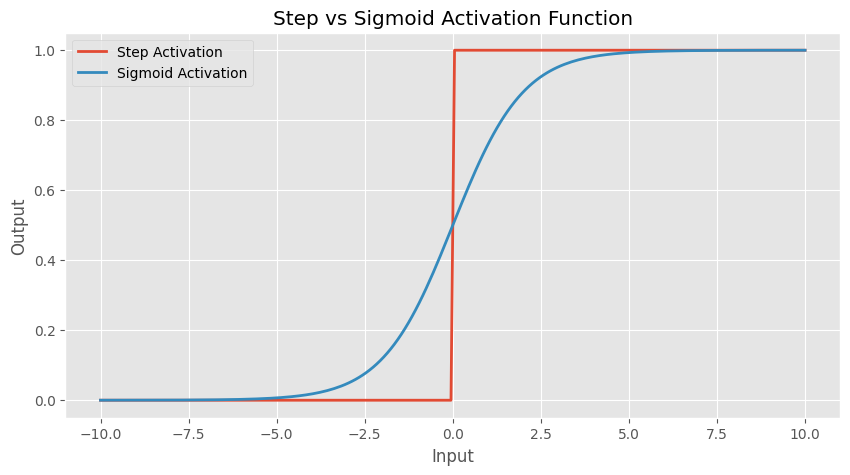

In [39]:
# Add. Task 1

# ============================================
# Step vs Sigmoid Activation Function
# ============================================

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)

# Step Activation
step = np.where(x >= 0, 1, 0)

# Sigmoid Activation
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(10,5))

plt.plot(x, step, label="Step Activation", linewidth=2)
plt.plot(x, sigmoid, label="Sigmoid Activation", linewidth=2)

plt.title("Step vs Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)

plt.show()

In [40]:

# Add. Task 2
# ============================================
# Comparison with Scikit-learn Perceptron
# ============================================

from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score
print(Perceptron)


sk_model = SklearnPerceptron(
    max_iter=50,
    eta0=0.01,
    random_state=42,
    tol=None
)

sk_model.fit(X_train, y_train)

y_pred_sk = sk_model.predict(X_test)

print("="*45)
print("Scikit-learn Perceptron")
print("="*45)

print("Accuracy :", accuracy_score(y_test, y_pred_sk))
print("Weights  :", sk_model.coef_)
print("Bias     :", sk_model.intercept_)

<class 'sklearn.linear_model._perceptron.Perceptron'>
Scikit-learn Perceptron
Accuracy : 0.9854545454545455
Weights  : [[-0.17997953 -0.18930979 -0.20601145 -0.00042665]]
Bias     : [0.25]


<class 'sklearn.linear_model._perceptron.Perceptron'>
Epoch 1
Misclassified Samples : 171
Weights : [-0.00679236 -0.00461728 -0.00590423  0.00221363]
Bias : 0.007
------------------------------------------------------------
Epoch 2
Misclassified Samples : 101
Weights : [-0.00838051 -0.00677447 -0.00810598  0.00077559]
Bias : 0.010000000000000002
------------------------------------------------------------
Epoch 3
Misclassified Samples : 43
Weights : [-0.00878054 -0.00782712 -0.00894526  0.00024027]
Bias : 0.011000000000000003
------------------------------------------------------------
Epoch 4
Misclassified Samples : 43
Weights : [-0.00908198 -0.00897889 -0.00912327  0.00043911]
Bias : 0.012000000000000004
------------------------------------------------------------
Epoch 5
Misclassified Samples : 57
Weights : [-0.00987896 -0.00982728 -0.00983637  0.00110804]
Bias : 0.013000000000000005
------------------------------------------------------------
Epoch 6
Misclassified Samples : 43
Weig

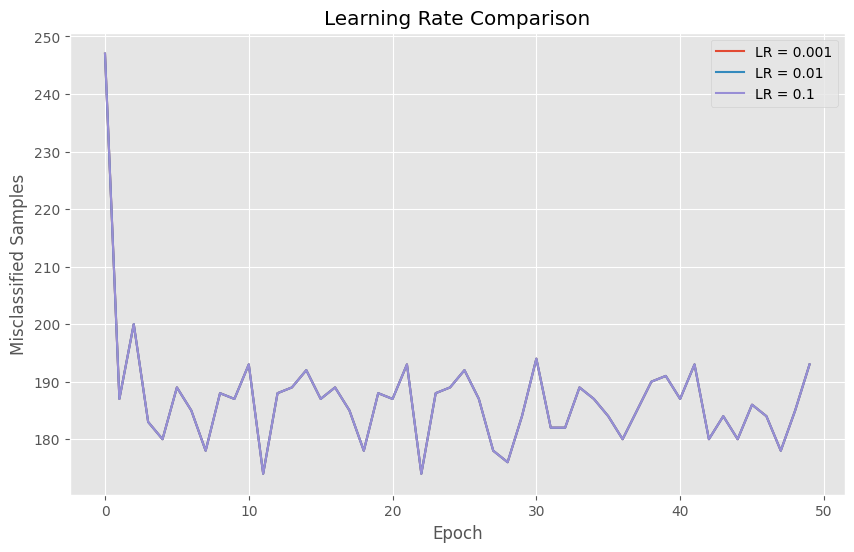

,Learning Rate,Accuracy
0,0.001,0.989091
1,0.010,0.989091
2,0.100,0.989091


In [43]:
# ============================================
# Learning Rate Comparison
# ============================================

from sklearn.linear_model import Perceptron
print(Perceptron)


learning_rates = [0.001, 0.01, 0.1]

results = []

plt.figure(figsize=(10,6))

for lr in learning_rates:

    mymodel = MyPerceptron(
        learning_rate=lr,
        epochs=50
    )

    mymodel.fit(X_train, y_train)

    predictions = mymodel.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    results.append([lr, acc])

    plt.plot(
        model.errors,
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.show()

comparison = pd.DataFrame(
    results,
    columns=["Learning Rate", "Accuracy"]
)

comparison


*Add. Task 4*


A Single Layer Perceptron cannot solve the XOR problem because XOR is not linearly separable. A single linear decision boundary cannot correctly separate all four XOR input combinations. Solving the XOR problem requires at least one hidden layer with nonlinear activation functions, which allows the network to learn more complex decision boundaries.

<class 'sklearn.linear_model._perceptron.Perceptron'>
Epoch 1
Misclassified Samples : 63
Weights : [-0.27346441 -0.17847759 -0.1938343  -0.0284236 ]
Bias : 0.21000000000000005
------------------------------------------------------------
Epoch 2
Misclassified Samples : 37
Weights : [-0.40417231 -0.27213259 -0.2643083  -0.11072639]
Bias : 0.3000000000000001
------------------------------------------------------------
Epoch 3
Misclassified Samples : 31
Weights : [-0.41099831 -0.34242269 -0.3323873  -0.06949858]
Bias : 0.37000000000000016
------------------------------------------------------------
Epoch 4
Misclassified Samples : 22
Weights : [-0.46037411 -0.34093269 -0.3612773  -0.02461929]
Bias : 0.3900000000000002
------------------------------------------------------------
Epoch 5
Misclassified Samples : 19
Weights : [-0.48088611 -0.35876879 -0.3688663  -0.04972263]
Bias : 0.4400000000000002
------------------------------------------------------------
Epoch 6
Misclassified Samples : 21

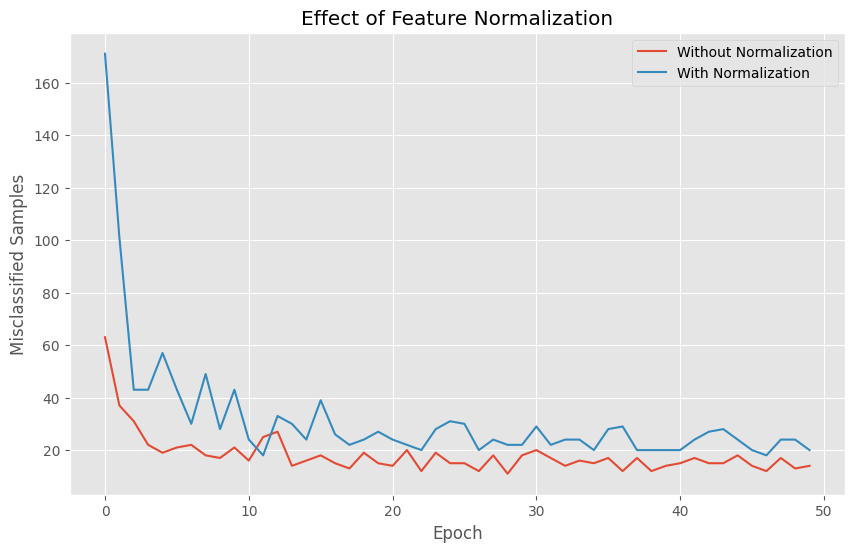

In [48]:
# Add. Task 5
# ============================================
# Effect of Feature Normalization
# ============================================

# Raw data (without normalization)
from sklearn.linear_model import Perceptron
print(Perceptron)
X_raw = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

# Normalized data
scaler = MinMaxScaler()

X_norm = scaler.fit_transform(X_raw)

X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    X_norm,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

# Train without normalization
model_raw = MyPerceptron(
    learning_rate=0.01,
    epochs=50
)

model_raw.fit(X_train_raw, y_train_raw)

# Train with normalization
model_norm = MyPerceptron(
    learning_rate=0.01,
    epochs=50
)

model_norm.fit(X_train_norm, y_train_norm)

plt.figure(figsize=(10,6))

plt.plot(
    model_raw.errors,
    label="Without Normalization"
)

plt.plot(
    model_norm.errors,
    label="With Normalization"
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Effect of Feature Normalization")

plt.legend()
plt.grid(True)

plt.show()